# Lectura 3: Fundamentos de Procesamiento de Lenguaje Natural

```{admonition} Ejecutar en Google Colab
:class: tip

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salvahin/ACA-2026/blob/main/book/notebooks/03_generacion_autoregresiva.ipynb)
```

In [1]:
# Setup Colab Environment
!pip install -q numpy pandas matplotlib seaborn scikit-learn torch transformers accelerate triton xgrammar nltk
print('Dependencies installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 31.2 MB/s eta 0:00:00
Dependencies installed!


```{admonition} Objetivos de Aprendizaje
:class: tip
Al finalizar esta lectura podrás:
- Aplicar técnicas de preprocesamiento de texto: tokenización, stemming, lematización
- Representar texto numéricamente usando n-grams, one-hot encoding y embeddings
- Comprender la evolución de RNNs a LSTMs/GRUs y sus limitantes (gradient vanishing)
- Explicar cómo BERT aprende embeddings semánticos con Masked Language Modeling
- Aplicar tokenización BPE para convertir texto a secuencias numéricas
- Entender la generación autoregresiva y estrategias de muestreo
```

```{admonition} 🎬 Video Recomendado
:class: tip

**[Word Embedding and Word2Vec (StatQuest)](https://www.youtube.com/watch?v=viZrOnJclY0)** - Explicación visual de cómo las palabras se convierten en vectores numéricos.
```

## Contexto
Esta lectura introduce los **fundamentos del Procesamiento de Lenguaje Natural (NLP)**. Antes de entender modelos modernos como Transformers (Lectura 4), necesitamos comprender cómo representar texto numéricamente y las técnicas clásicas que precedieron a la revolución del deep learning en NLP.

```{admonition} 📚 Prerequisito
:class: note
Antes de esta lección debes haber leido:
- **Lectura 1: Introducción al Aprendizaje Automático** — Paradigmas de IA y fundamentos
- **Lectura 2: Fundamentos de Deep Learning** — Redes neuronales, activaciones y backprop
```

## Introducción

El **Procesamiento de Lenguaje Natural (NLP)** es la rama de la IA que permite a las máquinas entender y generar lenguaje humano. Antes de que las redes neuronales dominaran este campo, los investigadores desarrollaron técnicas fundamentales que aún son relevantes hoy.

En esta lectura cubriremos:
1. **Preprocesamiento de texto**: cómo limpiar y normalizar datos textuales
2. **Representación de texto**: cómo convertir palabras en números
3. **Modelos secuenciales**: RNNs, LSTMs y sus limitaciones
4. **Embeddings semánticos**: Word2Vec y BERT
5. **Generación autoregresiva**: cómo los modelos generan texto token por token

---

## Parte 0: Conceptos Básicos de NLP

### Preprocesamiento de Texto

Antes de cualquier análisis, el texto debe limpiarse y normalizarse:

In [2]:
import re

# Texto de ejemplo
texto_raw = "Los GATOS están saltando! ¿No es increíble? Había 3 gatos en el jardín..."

print("Preprocesamiento de Texto")
print("=" * 60)
print(f"Texto original:\n  '{texto_raw}'")

# 1. Convertir a minúsculas
texto_lower = texto_raw.lower()
print(f"\n1. Minúsculas:\n  '{texto_lower}'")

# 2. Eliminar puntuación
texto_sin_punct = re.sub(r'[^\w\s]', '', texto_lower)
print(f"\n2. Sin puntuación:\n  '{texto_sin_punct}'")

# 3. Eliminar números (opcional)
texto_sin_num = re.sub(r'\d+', '', texto_sin_punct)
print(f"\n3. Sin números:\n  '{texto_sin_num}'")

# 4. Tokenización (dividir en palabras)
tokens = texto_sin_num.split()
print(f"\n4. Tokens:\n  {tokens}")

Preprocesamiento de Texto
Texto original:
  'Los GATOS están saltando! ¿No es increíble? Había 3 gatos en el jardín...'

1. Minúsculas:
  'los gatos están saltando! ¿no es increíble? había 3 gatos en el jardín...'

2. Sin puntuación:
  'los gatos están saltando no es increíble había 3 gatos en el jardín'

3. Sin números:
  'los gatos están saltando no es increíble había  gatos en el jardín'

4. Tokens:
  ['los', 'gatos', 'están', 'saltando', 'no', 'es', 'increíble', 'había', 'gatos', 'en', 'el', 'jardín']


### Tokenización

**Tokenización** es dividir texto en unidades más pequeñas (tokens):

```
Tipos de tokenización:
- Por palabras: "Hola mundo" → ["Hola", "mundo"]
- Por caracteres: "Hola" → ["H", "o", "l", "a"]
- Por subpalabras: "unhappy" → ["un", "happy"] (BPE, lo veremos después)
```

In [3]:
# Diferentes estrategias de tokenización
texto = "El gato saltó sobre la cerca"

# Tokenización por palabras (simple)
tokens_palabras = texto.split()
print(f"Por palabras: {tokens_palabras}")
print(f"  → {len(tokens_palabras)} tokens")

# Tokenización por caracteres
tokens_chars = list(texto.replace(" ", ""))
print(f"\nPor caracteres: {tokens_chars[:10]}...")
print(f"  → {len(tokens_chars)} tokens")

# El balance: subpalabras (BPE) - se verá en detalle más adelante
print("\nPor subpalabras (BPE): vocabulario limitado pero flexible")

Por palabras: ['El', 'gato', 'saltó', 'sobre', 'la', 'cerca']
  → 6 tokens

Por caracteres: ['E', 'l', 'g', 'a', 't', 'o', 's', 'a', 'l', 't']...
  → 23 tokens

Por subpalabras (BPE): vocabulario limitado pero flexible


### Stemming y Lematización

Reducir palabras a su forma base:

In [4]:
# Stemming: cortar sufijos (reglas simples)
def stemming_simple(palabra):
    """Stemming muy básico para español"""
    sufijos = ['ando', 'endo', 'aba', 'ía', 'aron', 'ieron', 'es', 's']
    for sufijo in sufijos:
        if palabra.endswith(sufijo) and len(palabra) > len(sufijo) + 2:
            return palabra[:-len(sufijo)]
    return palabra

palabras = ['saltando', 'saltaba', 'saltaron', 'gatos', 'casas']
print("Stemming (cortar sufijos):")
for palabra in palabras:
    print(f"  {palabra} → {stemming_simple(palabra)}")

print("\nLematización (forma de diccionario):")
print("  saltando → saltar (verbo infinitivo)")
print("  gatos → gato (singular)")
print("  mejores → bueno (adjetivo base)")
print("\n  Nota: La lematización requiere un diccionario, no solo reglas.")

Stemming (cortar sufijos):
  saltando → salt
  saltaba → salt
  saltaron → salt
  gatos → gato
  casas → casa

Lematización (forma de diccionario):
  saltando → saltar (verbo infinitivo)
  gatos → gato (singular)
  mejores → bueno (adjetivo base)

  Nota: La lematización requiere un diccionario, no solo reglas.


### N-gramas

**N-gramas** son secuencias de N tokens consecutivos:

In [5]:
def generar_ngrams(tokens, n):
    """Genera n-gramas de una lista de tokens"""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

tokens = ["el", "gato", "saltó", "sobre", "la", "cerca"]

print("N-gramas:")
print(f"Tokens: {tokens}\n")

for n in [1, 2, 3]:
    ngrams = generar_ngrams(tokens, n)
    print(f"{n}-gramas ({len(ngrams)} total):")
    for ng in ngrams[:5]:  # Mostrar solo primeros 5
        print(f"  {ng}")
    if len(ngrams) > 5:
        print(f"  ...")
    print()

print("Uso de n-gramas:")
print("  - Modelado de lenguaje clásico (predecir siguiente palabra)")
print("  - Detección de spam (bigramas frecuentes)")
print("  - Análisis de sentimiento (frases clave)")

N-gramas:
Tokens: ['el', 'gato', 'saltó', 'sobre', 'la', 'cerca']

1-gramas (6 total):
  ('el',)
  ('gato',)
  ('saltó',)
  ('sobre',)
  ('la',)
  ...

2-gramas (5 total):
  ('el', 'gato')
  ('gato', 'saltó')
  ('saltó', 'sobre')
  ('sobre', 'la')
  ('la', 'cerca')

3-gramas (4 total):
  ('el', 'gato', 'saltó')
  ('gato', 'saltó', 'sobre')
  ('saltó', 'sobre', 'la')
  ('sobre', 'la', 'cerca')

Uso de n-gramas:
  - Modelado de lenguaje clásico (predecir siguiente palabra)
  - Detección de spam (bigramas frecuentes)
  - Análisis de sentimiento (frases clave)


### One-Hot Encoding

Representar cada palabra como un vector binario:

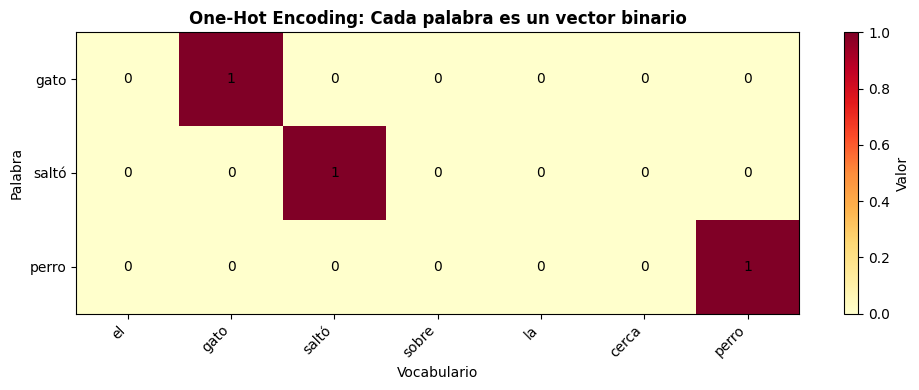

Problemas del One-Hot Encoding:
  1. Vectores muy grandes (vocab de 50,000 → vectores de 50,000 dims)
  2. No captura similitud ('gato' y 'perro' son igual de diferentes que 'gato' y 'mesa')
  3. Vectores dispersos (la mayoría son ceros)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Vocabulario pequeño
vocabulario = ["el", "gato", "saltó", "sobre", "la", "cerca", "perro"]
vocab_size = len(vocabulario)

# Crear one-hot encodings
palabra_a_indice = {palabra: i for i, palabra in enumerate(vocabulario)}

def one_hot(palabra, vocabulario):
    """Convierte una palabra a one-hot vector"""
    vec = np.zeros(len(vocabulario))
    if palabra in palabra_a_indice:
        vec[palabra_a_indice[palabra]] = 1
    return vec

# Visualizar
fig, ax = plt.subplots(figsize=(10, 4))

palabras_ejemplo = ["gato", "saltó", "perro"]
vectors = np.array([one_hot(p, vocabulario) for p in palabras_ejemplo])

im = ax.imshow(vectors, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(palabras_ejemplo)))
ax.set_yticklabels(palabras_ejemplo)
ax.set_xticks(range(vocab_size))
ax.set_xticklabels(vocabulario, rotation=45, ha='right')
ax.set_xlabel('Vocabulario')
ax.set_ylabel('Palabra')
ax.set_title('One-Hot Encoding: Cada palabra es un vector binario', fontsize=12, weight='bold')

# Añadir valores
for i in range(len(palabras_ejemplo)):
    for j in range(vocab_size):
        ax.text(j, i, int(vectors[i, j]), ha='center', va='center', fontsize=10)

plt.colorbar(im, ax=ax, label='Valor')
plt.tight_layout()
plt.show()

print("Problemas del One-Hot Encoding:")
print("  1. Vectores muy grandes (vocab de 50,000 → vectores de 50,000 dims)")
print("  2. No captura similitud ('gato' y 'perro' son igual de diferentes que 'gato' y 'mesa')")
print("  3. Vectores dispersos (la mayoría son ceros)")

### Vocabulario

El **vocabulario** es el conjunto de todos los tokens únicos:

```
Corpus: "el gato saltó. el perro corrió."
Vocabulario: {"el", "gato", "saltó", ".", "perro", "corrió"}
Tamaño del vocabulario: 6

Problema: ¿Qué pasa con palabras nuevas?
  → Token especial [UNK] (unknown)
  → O mejor: usar subpalabras (BPE) que veremos después
```

---

## Parte 1: De Palabras a Vectores (Embeddings)

### El Problema del One-Hot

One-hot encoding tiene limitaciones graves. Necesitamos representaciones **densas** que capturen **similitud semántica**.

Similitud Coseno entre Embeddings
  sim('gato', 'perro') = 0.999
  sim('gato', 'mesa') = 0.303
  sim('mesa', 'silla') = 0.996
  sim('correr', 'saltar') = 0.991


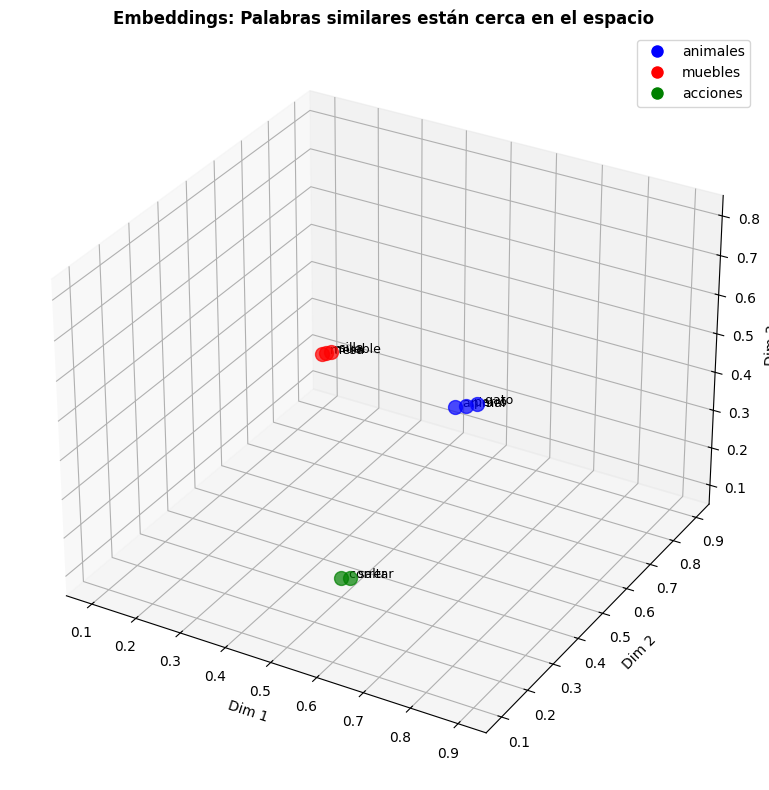


Ventajas de Embeddings:
  1. Vectores densos (100-1000 dims vs 50,000)
  2. Capturan similitud semántica
  3. Se pueden aprender de datos


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación de embeddings semánticos (en realidad se aprenden)
# Vectores de 3 dimensiones para visualización
embeddings = {
    "gato": np.array([0.9, 0.1, 0.8]),
    "perro": np.array([0.85, 0.15, 0.75]),
    "animal": np.array([0.8, 0.2, 0.7]),
    "mesa": np.array([0.1, 0.9, 0.2]),
    "silla": np.array([0.15, 0.85, 0.25]),
    "mueble": np.array([0.12, 0.88, 0.22]),
    "correr": np.array([0.5, 0.3, 0.1]),
    "saltar": np.array([0.55, 0.25, 0.15]),
}

# Calcular similitudes (producto punto normalizado = coseno)
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print("Similitud Coseno entre Embeddings")
print("=" * 50)
pares = [("gato", "perro"), ("gato", "mesa"), ("mesa", "silla"), ("correr", "saltar")]
for p1, p2 in pares:
    sim = cosine_similarity(embeddings[p1], embeddings[p2])
    print(f"  sim('{p1}', '{p2}') = {sim:.3f}")

# Visualización 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'animales': 'blue', 'muebles': 'red', 'acciones': 'green'}
categorias = {
    'gato': 'animales', 'perro': 'animales', 'animal': 'animales',
    'mesa': 'muebles', 'silla': 'muebles', 'mueble': 'muebles',
    'correr': 'acciones', 'saltar': 'acciones'
}

for palabra, vec in embeddings.items():
    cat = categorias[palabra]
    ax.scatter(vec[0], vec[1], vec[2], c=colors[cat], s=100, alpha=0.7)
    ax.text(vec[0], vec[1], vec[2], f'  {palabra}', fontsize=9)

ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.set_zlabel('Dim 3')
ax.set_title('Embeddings: Palabras similares están cerca en el espacio', fontsize=12, weight='bold')

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=cat)
                   for cat, c in colors.items()]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print("\nVentajas de Embeddings:")
print("  1. Vectores densos (100-1000 dims vs 50,000)")
print("  2. Capturan similitud semántica")
print("  3. Se pueden aprender de datos")

### Word2Vec y Embeddings Pre-entrenados

**Word2Vec** (2013) fue revolucionario: entrenar embeddings prediciendo palabras del contexto.

```
Dos arquitecturas:
1. CBOW (Continuous Bag of Words): predice palabra del contexto
   Contexto: "el ___ saltó" → Predecir: "gato"

2. Skip-gram: predice contexto de la palabra
   Palabra: "gato" → Predecir: "el", "saltó"
```

```{admonition} 📚 Referencia: BERT y Embeddings Contextuales
:class: seealso
Word2Vec produce un embedding **fijo** por palabra. Pero "banco" (financiero) y "banco" (de parque) tienen el mismo vector.

**BERT** (Devlin et al., 2019) resuelve esto con **embeddings contextuales**: el vector de una palabra depende de su contexto.

Paper: [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)

Veremos BERT en detalle más adelante en esta lectura y profundizaremos en la Lectura 4.
```

---

## Parte 1.5: Modelos Secuenciales y sus Limitaciones

### RNNs para Secuencias

Las **Redes Neuronales Recurrentes (RNNs)** fueron diseñadas para procesar secuencias:

```
Entrada: "El gato saltó"

Paso 1: procesa "El" → produce Estado₁
Paso 2: procesa "gato" + Estado₁ → produce Estado₂
Paso 3: procesa "saltó" + Estado₂ → produce Estado₃

El estado "recuerda" información de pasos anteriores.
```

In [8]:
import numpy as np

# Simulación conceptual de RNN
def rnn_step(x, h_prev, Wx, Wh, b):
    """Un paso de RNN: combina input actual con estado previo"""
    return np.tanh(Wx @ x + Wh @ h_prev + b)

# Parámetros (simplificados)
np.random.seed(42)
hidden_size = 4
input_size = 3

Wx = np.random.randn(hidden_size, input_size) * 0.1
Wh = np.random.randn(hidden_size, hidden_size) * 0.1
b = np.zeros(hidden_size)

# Secuencia de entrada (3 palabras, cada una con embedding de 3 dims)
palabras = ["el", "gato", "saltó"]
embeddings_seq = [np.random.randn(input_size) for _ in palabras]

# Procesar secuencia
h = np.zeros(hidden_size)  # Estado inicial
estados = [h.copy()]

print("Simulación de RNN")
print("=" * 50)
for i, (palabra, x) in enumerate(zip(palabras, embeddings_seq)):
    h = rnn_step(x, h, Wx, Wh, b)
    estados.append(h.copy())
    print(f"Paso {i+1}: '{palabra}' → Estado: {h.round(3)}")

print(f"\nEstado final contiene información de TODA la secuencia")

Simulación de RNN
Paso 1: 'el' → Estado: [-0.065 -0.07  -0.089  0.009]
Paso 2: 'gato' → Estado: [0.05  0.308 0.32  0.162]
Paso 3: 'saltó' → Estado: [-0.051  0.101  0.006  0.061]

Estado final contiene información de TODA la secuencia


### El Problema del Gradient Vanishing

**Problema crítico:** En secuencias largas, el gradiente se desvanece.

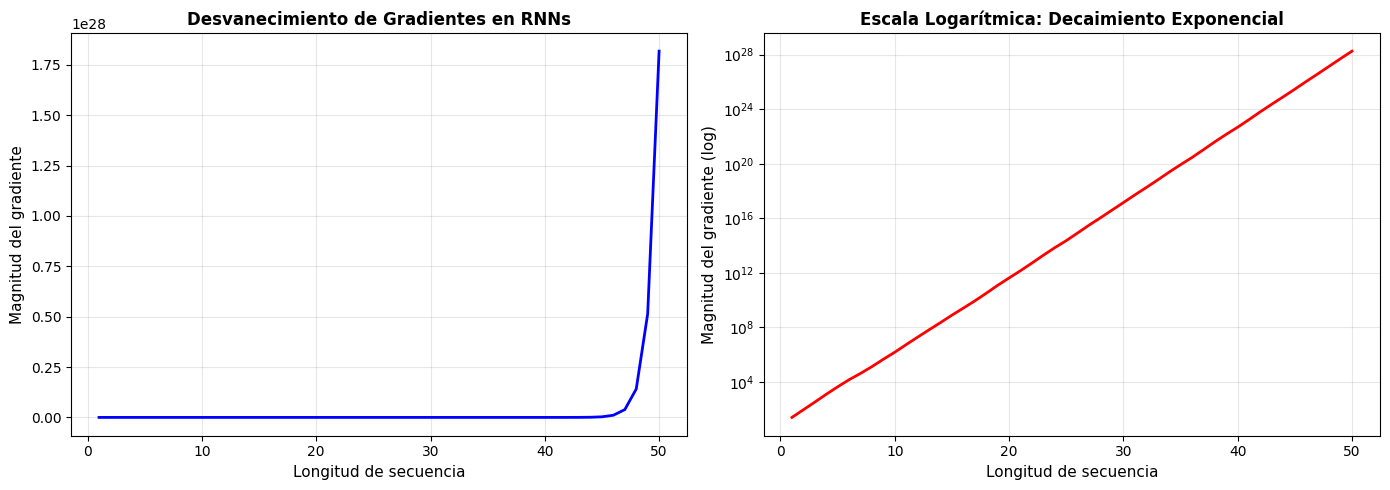

Consecuencias del Gradient Vanishing:
  1. Las capas iniciales NO aprenden (gradiente ≈ 0)
  2. El modelo 'olvida' información de hace muchos pasos
  3. Dependencias de largo plazo son imposibles de aprender

Esto motivó el desarrollo de LSTMs, GRUs, y finalmente Transformers.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación del desvanecimiento de gradientes
seq_lengths = range(1, 51)
gradient_magnitudes = []

# Simular multiplicación repetida de matrices
np.random.seed(42)
W = np.random.randn(50, 50) * 0.5  # Pesos típicos < 1

for length in seq_lengths:
    grad = np.ones(50)  # Gradiente inicial
    for _ in range(length):
        grad = W.T @ grad  # Backprop a través de una capa
    gradient_magnitudes.append(np.linalg.norm(grad))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica lineal
axes[0].plot(seq_lengths, gradient_magnitudes, 'b-', linewidth=2)
axes[0].set_xlabel('Longitud de secuencia', fontsize=11)
axes[0].set_ylabel('Magnitud del gradiente', fontsize=11)
axes[0].set_title('Desvanecimiento de Gradientes en RNNs', fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3)

# Gráfica logarítmica
axes[1].semilogy(seq_lengths, gradient_magnitudes, 'r-', linewidth=2)
axes[1].set_xlabel('Longitud de secuencia', fontsize=11)
axes[1].set_ylabel('Magnitud del gradiente (log)', fontsize=11)
axes[1].set_title('Escala Logarítmica: Decaimiento Exponencial', fontsize=12, weight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Consecuencias del Gradient Vanishing:")
print("  1. Las capas iniciales NO aprenden (gradiente ≈ 0)")
print("  2. El modelo 'olvida' información de hace muchos pasos")
print("  3. Dependencias de largo plazo son imposibles de aprender")
print("\nEsto motivó el desarrollo de LSTMs, GRUs, y finalmente Transformers.")

### LSTMs: Puertas de Memoria

Las **Long Short-Term Memory (LSTM)** networks agregan "puertas" para controlar el flujo de información:

```
LSTM tiene 3 puertas:
1. Puerta de Olvido (forget gate): ¿Qué información descartar?
2. Puerta de Entrada (input gate): ¿Qué información nueva agregar?
3. Puerta de Salida (output gate): ¿Qué información exponer?

Ventaja: La celda de memoria puede mantener información por muchos pasos.
Problema: Sigue siendo secuencial → lento y aún tiene límites.
```

```{admonition} 🔮 Motivación para Transformers
:class: important
Las RNNs y LSTMs tienen limitaciones fundamentales:
1. **Procesamiento secuencial**: no paralelizable, lento
2. **Gradient vanishing** (aunque LSTMs lo mitigan, no lo eliminan)
3. **Dependencias muy largas** siguen siendo difíciles

La arquitectura **Transformer** (Lectura 4) resuelve todos estos problemas con el mecanismo de **atención**, permitiendo que cada palabra "vea" directamente a todas las demás.
```

---

## Parte 2: BERT y Embeddings Contextuales

### ¿Qué es BERT?

**BERT** (Bidirectional Encoder Representations from Transformers) revolucionó NLP en 2018.

```
Diferencia clave con Word2Vec:
- Word2Vec: "banco" siempre tiene el mismo vector
- BERT: "banco financiero" vs "banco del parque" → vectores DIFERENTES

BERT ve el contexto COMPLETO (bidireccional) antes de producir el embedding.
```

### Pre-entrenamiento de BERT: Masked Language Modeling

BERT se entrena con **Masked Language Modeling (MLM)**:

```
Entrada:  "El [MASK] saltó sobre la cerca"
Objetivo: Predecir "gato"

Se enmascara ~15% de los tokens y el modelo aprende a predecirlos.
Esto fuerza al modelo a entender el contexto bidireccional.
```

In [10]:
# Simulación conceptual de MLM
import numpy as np

oracion = ["El", "gato", "saltó", "sobre", "la", "cerca"]
print("Masked Language Modeling (MLM)")
print("=" * 50)

# Mostrar ejemplos de masking
np.random.seed(42)
for i in range(3):
    mask_idx = np.random.randint(0, len(oracion))
    masked = oracion.copy()
    original = masked[mask_idx]
    masked[mask_idx] = "[MASK]"
    print(f"\nEjemplo {i+1}:")
    print(f"  Input:    {' '.join(masked)}")
    print(f"  Target:   Predecir '{original}'")
    print(f"  Contexto: BERT ve todas las palabras excepto la enmascarada")

print("\n" + "=" * 50)
print("Resultado del entrenamiento:")
print("  - BERT aprende representaciones CONTEXTUALES")
print("  - El mismo token tiene diferente embedding según el contexto")
print("  - Captura relaciones semánticas profundas")

Masked Language Modeling (MLM)

Ejemplo 1:
  Input:    El gato saltó [MASK] la cerca
  Target:   Predecir 'sobre'
  Contexto: BERT ve todas las palabras excepto la enmascarada

Ejemplo 2:
  Input:    El gato saltó sobre [MASK] cerca
  Target:   Predecir 'la'
  Contexto: BERT ve todas las palabras excepto la enmascarada

Ejemplo 3:
  Input:    El gato [MASK] sobre la cerca
  Target:   Predecir 'saltó'
  Contexto: BERT ve todas las palabras excepto la enmascarada

Resultado del entrenamiento:
  - BERT aprende representaciones CONTEXTUALES
  - El mismo token tiene diferente embedding según el contexto
  - Captura relaciones semánticas profundas


```{admonition} 📖 Para Profundizar
:class: seealso
BERT usa la arquitectura Transformer (encoder only) que veremos en detalle en la **Lectura 4**.

Por ahora, lo importante es entender que BERT produce embeddings que:
1. Dependen del contexto completo
2. Son pre-entrenados en grandes cantidades de texto
3. Se pueden "afinar" (fine-tune) para tareas específicas
```

---

## Parte 3: Generación Autoregresiva

Ahora que entendemos cómo representar texto, veamos cómo los modelos **generan** texto nuevo.

### El Proceso Autoregresivo

Los modelos generativos (como GPT) producen texto **token por token**:

:::{figure} images/AI_03_02_Softmax_Funcion_Visualization.jpeg
:name: fig-softmax-visualization
:alt: Visualización de la función softmax en generación
:align: center
:width: 90%

**Figura 1:** Función Softmax - convierte logits en probabilidades normalizadas para seleccionar el siguiente token.
:::

### Salida del Modelo

Un modelo de lenguaje toma una secuencia y produce:

```
Entrada:  "El gato saltó"
              ↓
          [Transformer]
              ↓
Salida:   Vector para "el", Vector para "gato", Vector para "saltó"

Cada vector representa la información contextualizada de esa palabra.
```

Para generación, usamos el vector de la **última palabra** como entrada a una capa de predicción:

```
Última salida del Transformer: [0.2, -0.5, 0.8, ..., 0.1]  (768-dimensional)
                                      ↓
                          [Proyección Linear]
                                      ↓
                          [Logits para 50,257 tokens]
                                      ↓
                                    Salida:
                                    Token 0 (PAD): logit = 2.3
                                    Token 1 (EOS): logit = 0.5
                                    ...
                                    Token 250 ("el"): logit = 8.1
                                    Token 251 ("gato"): logit = 7.9
                                    Token 252 ("saltó"): logit = 6.2
                                    ...
                                    Token 50256 (UNK): logit = -2.1
```

Los **logits** son números sin restricción. Necesitamos convertirlos en probabilidades.

---

## Parte 2: De Logits a Probabilidades

### Softmax

Softmax convierte logits en una distribución de probabilidad:

```
Sea logits = [2.3, 0.5, 8.1, 7.9, 6.2, ..., -2.1]

Paso 1: Exponencial
  exp(logits) = [e^2.3, e^0.5, e^8.1, e^7.9, e^6.2, ..., e^-2.1]
              = [9.97, 1.65, 3,320.1, 2,980.96, 493.8, ..., 0.12]

Paso 2: Normaliza
  suma = 9.97 + 1.65 + 3,320.1 + 2,980.96 + 493.8 + ... + 0.12

  probabilidades = exp(logits) / suma
                 = [9.97/suma, 1.65/suma, 3,320.1/suma, ...]
```

Conversión de Logits a Probabilidades con Softmax

Token           Logit      exp(Logit)    Probabilidad
------------------------------------------------------------
PAD              2.30            9.97         0.0015 (0.15%)
EOS              0.50            1.65         0.0003 (0.03%)
el               8.10         3294.47         0.5044 (50.44%)
gato             7.90         2697.28         0.4129 (41.29%)
saltó            6.20          492.75         0.0754 (7.54%)
perro           -2.10            0.12         0.0000 (0.00%)
casa             1.00            2.72         0.0004 (0.04%)
corre            3.50           33.12         0.0051 (0.51%)
------------------------------------------------------------
TOTAL                                         1.0000 (100.00%)


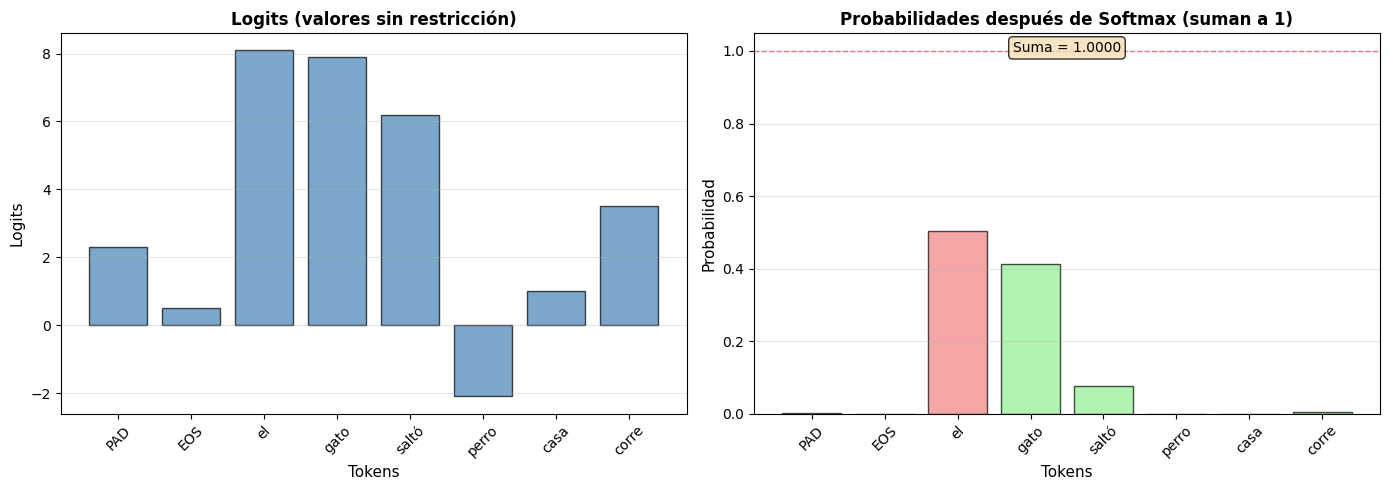


Token con mayor probabilidad: 'el' (50.44%)


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(logits):
    """Implementación numerically stable de softmax"""
    # Restar el máximo para estabilidad numérica
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / np.sum(exp_logits)

# Ejemplo con tokens
logits = np.array([2.3, 0.5, 8.1, 7.9, 6.2, -2.1, 1.0, 3.5])
tokens = ['PAD', 'EOS', 'el', 'gato', 'saltó', 'perro', 'casa', 'corre']

# Calcular probabilidades
probs = softmax(logits)

print("Conversión de Logits a Probabilidades con Softmax")
print("=" * 60)
print(f"\n{'Token':<10} {'Logit':>10} {'exp(Logit)':>15} {'Probabilidad':>15}")
print("-" * 60)

for token, logit, prob in zip(tokens, logits, probs):
    print(f"{token:<10} {logit:>10.2f} {np.exp(logit):>15.2f} {prob:>14.4f} ({prob*100:.2f}%)")

print("-" * 60)
print(f"{'TOTAL':<10} {'':<10} {'':<15} {probs.sum():>14.4f} (100.00%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de logits
axes[0].bar(tokens, logits, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Tokens', fontsize=11)
axes[0].set_ylabel('Logits', fontsize=11)
axes[0].set_title('Logits (valores sin restricción)', fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Gráfica de probabilidades
colors = ['lightcoral' if p == max(probs) else 'lightgreen' for p in probs]
axes[1].bar(tokens, probs, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Tokens', fontsize=11)
axes[1].set_ylabel('Probabilidad', fontsize=11)
axes[1].set_title('Probabilidades después de Softmax (suman a 1)', fontsize=12, weight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Agregar línea de suma
axes[1].text(0.5, 0.95, f'Suma = {probs.sum():.4f}',
             transform=axes[1].transAxes, ha='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nToken con mayor probabilidad: '{tokens[np.argmax(probs)]}' ({probs.max()*100:.2f}%)")

Resultado: probabilidades que suman a 1.

```
Interpretación:
Token 250 ("el"): 0.15  (15% de probabilidad)
Token 251 ("gato"): 0.14 (14% de probabilidad)
Token 252 ("saltó"): 0.023 (2.3% de probabilidad)
...
```

### Temperatura

Un parámetro importante modifica la "agudeza" de la distribución:

```
Logits modificados = logits / T

donde T es la temperatura (típicamente entre 0.1 y 2.0)
```

:::{figure} images/AI_03_01_Beam_Search_Visualization.jpeg
:name: fig-beam-search
:alt: Visualización de Beam Search
:align: center
:width: 90%

**Figura 2:** Beam Search - explora múltiples caminos simultáneamente manteniendo los K mejores candidatos.
:::

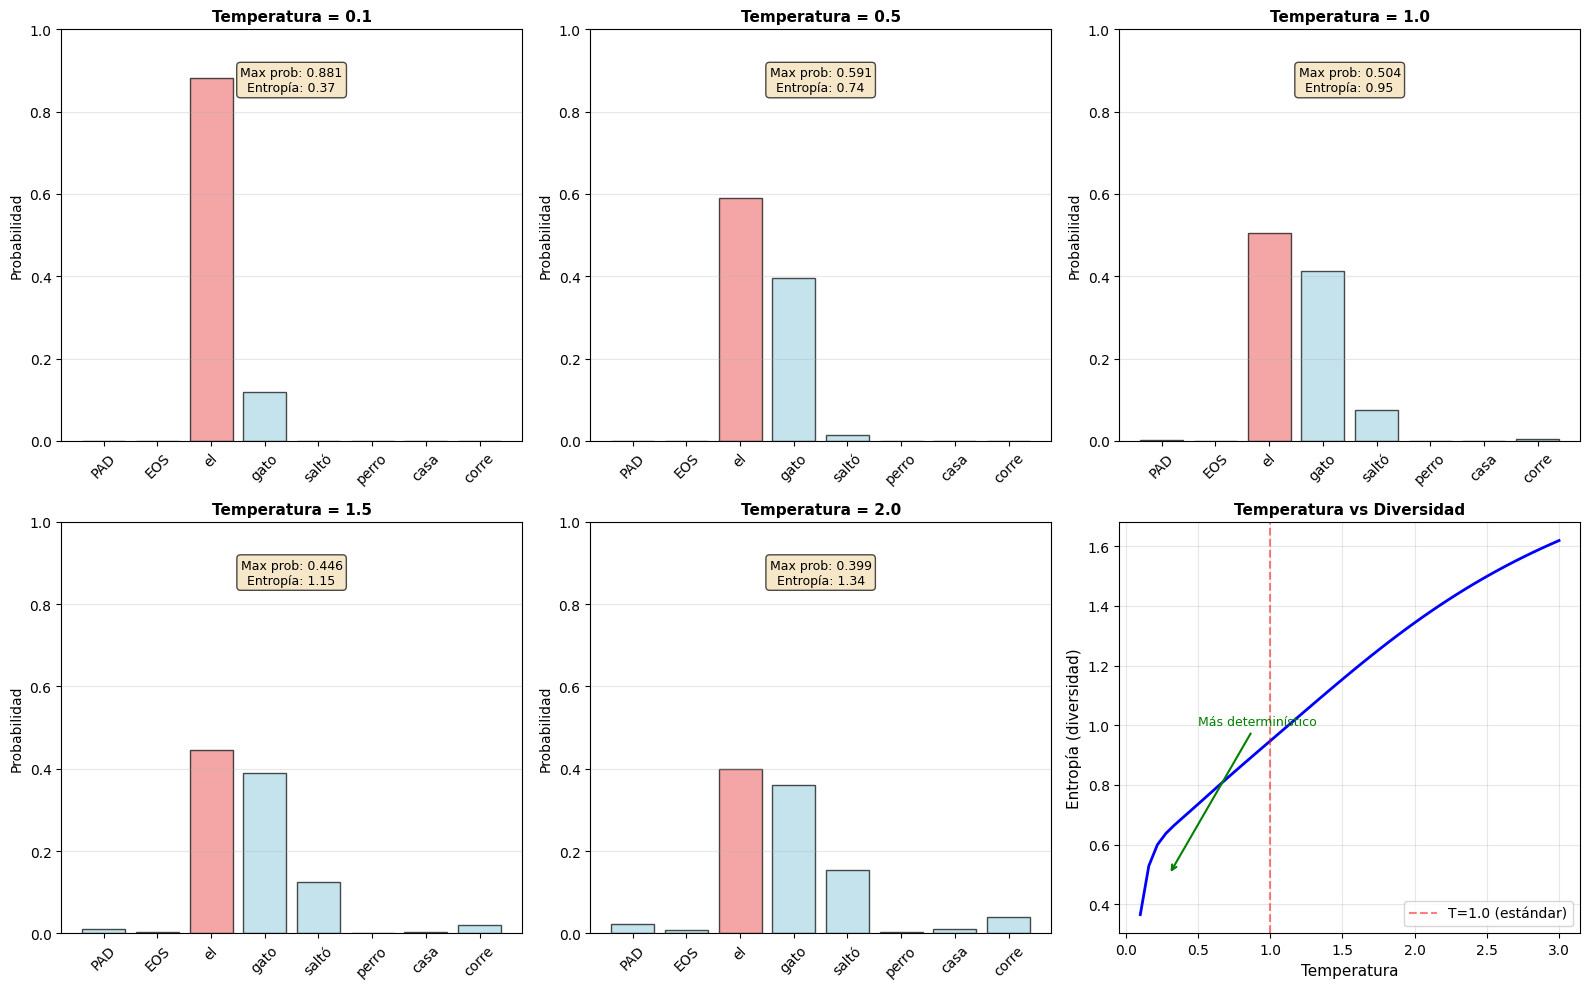

Efecto de la Temperatura:
T=0.1: Token más probable = 'el' (88.1%)
T=0.5: Token más probable = 'el' (59.1%)
T=1.0: Token más probable = 'el' (50.4%)
T=2.0: Token más probable = 'el' (39.9%)


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / np.sum(exp_logits)

def apply_temperature(logits, temperature):
    return logits / temperature

# Logits de ejemplo
logits = np.array([2.3, 0.5, 8.1, 7.9, 6.2, -2.1, 1.0, 3.5])
tokens = ['PAD', 'EOS', 'el', 'gato', 'saltó', 'perro', 'casa', 'corre']

# Diferentes temperaturas
temperatures = [0.1, 0.5, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, temp in enumerate(temperatures):
    # Aplicar temperatura
    scaled_logits = apply_temperature(logits, temp)
    probs = softmax(scaled_logits)

    # Visualizar
    ax = axes[idx]
    colors = ['lightcoral' if p == max(probs) else 'lightblue' for p in probs]
    ax.bar(tokens, probs, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probabilidad', fontsize=10)
    ax.set_title(f'Temperatura = {temp:.1f}', fontsize=11, weight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.0)

    # Añadir estadísticas
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    max_prob = np.max(probs)
    ax.text(0.5, 0.85, f'Max prob: {max_prob:.3f}\nEntropía: {entropy:.2f}',
            transform=ax.transAxes, ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Último subplot: comparación de entropías
ax = axes[-1]
entropies = []
for temp in np.linspace(0.1, 3.0, 50):
    probs = softmax(apply_temperature(logits, temp))
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    entropies.append(entropy)

temp_range = np.linspace(0.1, 3.0, 50)
ax.plot(temp_range, entropies, 'b-', linewidth=2)
ax.set_xlabel('Temperatura', fontsize=11)
ax.set_ylabel('Entropía (diversidad)', fontsize=11)
ax.set_title('Temperatura vs Diversidad', fontsize=11, weight='bold')
ax.grid(True, alpha=0.3)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='T=1.0 (estándar)')
ax.legend()

# Añadir anotaciones
ax.annotate('Más determinístico', xy=(0.3, 0.5), xytext=(0.5, 1.0),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            fontsize=9, color='green')
ax.annotate('Más aleatorio', xy=(2.5, 1.8), xytext=(2.0, 1.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=9, color='red')

plt.tight_layout()
plt.show()

print("Efecto de la Temperatura:")
print("=" * 60)
for temp in [0.1, 0.5, 1.0, 2.0]:
    probs = softmax(apply_temperature(logits, temp))
    top_token = tokens[np.argmax(probs)]
    top_prob = np.max(probs)
    print(f"T={temp:.1f}: Token más probable = '{top_token}' ({top_prob*100:.1f}%)")

**Efecto:**
- T bajo → Generación determinística, coherente, potencialmente repetitiva
- T alto → Generación creativa, pero potencialmente incoherente

```{admonition} 🎮 Simulación Interactiva: Efecto de Temperatura
:class: tip

Explora cómo la temperatura afecta la distribución de probabilidades de manera interactiva.
```

In [13]:
# Simulación del efecto de temperatura en softmax
import numpy as np
import plotly.graph_objects as go

logits = np.array([2.0, 1.0, 0.5, 0.1, -0.5])
tokens = ['el', 'un', 'una', 'mi', 'su']

temperatures = [0.1, 0.5, 1.0, 1.5, 2.0]
fig = go.Figure()

for T in temperatures:
    probs = np.exp(logits/T) / np.sum(np.exp(logits/T))
    fig.add_trace(go.Bar(name=f'T={T}', x=tokens, y=probs))

fig.update_layout(
    barmode='group',
    title='Efecto de Temperatura en Distribución de Probabilidades',
    xaxis_title='Token',
    yaxis_title='Probabilidad',
    height=400
)
fig.show()

```{admonition} 🤔 Reflexiona
:class: hint
¿Por qué crees que un chatbot interactivo usa T=1.0 pero un traductor automático usa T=0.1? Piensa en qué priorizas en cada caso: creatividad o precisión.
```

---

## Parte 3: Estrategias de Muestreo (Decoding)

Ahora tenemos probabilidades para cada token. ¿Cuál elegimos?

### Greedy Decoding

```
Elige el token con la probabilidad más alta:

P("el") = 0.15
P("gato") = 0.14
P("saltó") = 0.023
...

Elige "el" (máxima probabilidad)

Repetir:
Entrada: "El gato saltó el"
           ↓
       [Transformer]
           ↓
Siguiente token más probable: "perro" (P = 0.18)

Entrada: "El gato saltó el perro"
...
```

**Ventaja:** Rápido, determinístico
**Desventaja:** A menudo genera texto monotonía o poco creativo

### Top-K Sampling

```
1. Ordena los tokens por probabilidad
2. Mantén solo los top K tokens
3. Renormaliza sus probabilidades
4. Muestra aleatoriamente de esa distribución

Ejemplo (K=5):
Original:       P("el")=0.15, P("gato")=0.14, P("saltó")=0.023, P("perro")=0.01, ...
Top-5 tokens:   P("el")=0.15, P("gato")=0.14, P("saltó")=0.023, P("corre")=0.015, P("perro")=0.01
Renormalizado:  P("el")=0.32, P("gato")=0.30, P("saltó")=0.05, P("corre")=0.03, P("perro")=0.02

Muestra aleatoriamente: 32% de probabilidad de "el", 30% de "gato", etc.
```

**Ventaja:** Excluye tokens muy improbables (tontos), pero mantiene diversidad
**Desventaja:** K es fijo; a veces queremos top-10, a veces top-3

### Top-P (Nucleus) Sampling

```
1. Ordena tokens por probabilidad (descendente)
2. Suma probabilidades de mayor a menor
3. Detén cuando la suma exceda P (típicamente 0.9)
4. Renormaliza esos tokens
5. Muestra

Ejemplo (P=0.9):
P("el")=0.35
P("el") + P("gato")=0.35+0.32=0.67
P("el") + P("gato") + P("saltó")=0.67+0.18=0.85
P("el") + P("gato") + P("saltó") + P("corre")=0.85+0.07=0.92 > 0.9 (STOP)

Tokens seleccionados: "el", "gato", "saltó", "corre"
Renormaliza y muestrea de esos.
```

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / np.sum(exp_logits)

def greedy_sampling(probs):
    """Selecciona el token con mayor probabilidad"""
    return np.argmax(probs)

def top_k_sampling(probs, k=5):
    """Top-K sampling"""
    top_k_indices = np.argsort(probs)[-k:]
    top_k_probs = probs[top_k_indices]
    # Renormalizar
    top_k_probs = top_k_probs / np.sum(top_k_probs)
    # Muestrear
    return np.random.choice(top_k_indices, p=top_k_probs)

def top_p_sampling(probs, p=0.9):
    """Top-P (Nucleus) sampling"""
    sorted_indices = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_indices]

    # Acumular probabilidades
    cumsum_probs = np.cumsum(sorted_probs)

    # Encontrar el núcleo
    nucleus_size = np.searchsorted(cumsum_probs, p) + 1
    nucleus_indices = sorted_indices[:nucleus_size]
    nucleus_probs = sorted_probs[:nucleus_size]

    # Renormalizar
    nucleus_probs = nucleus_probs / np.sum(nucleus_probs)

    # Muestrear
    return np.random.choice(nucleus_indices, p=nucleus_probs)

# Datos de ejemplo
logits = np.array([2.3, 0.5, 8.1, 7.9, 6.2, -2.1, 1.0, 3.5])
tokens = ['PAD', 'EOS', 'el', 'gato', 'saltó', 'perro', 'casa', 'corre']
probs = softmax(logits)

Podemos ver visualmente cómo se distribuyen estas probabilidades tras aplicar las estrategias de *Sampling* para "recortar" o enfatizar ciertas decisiones durante el decoding algorítmico.

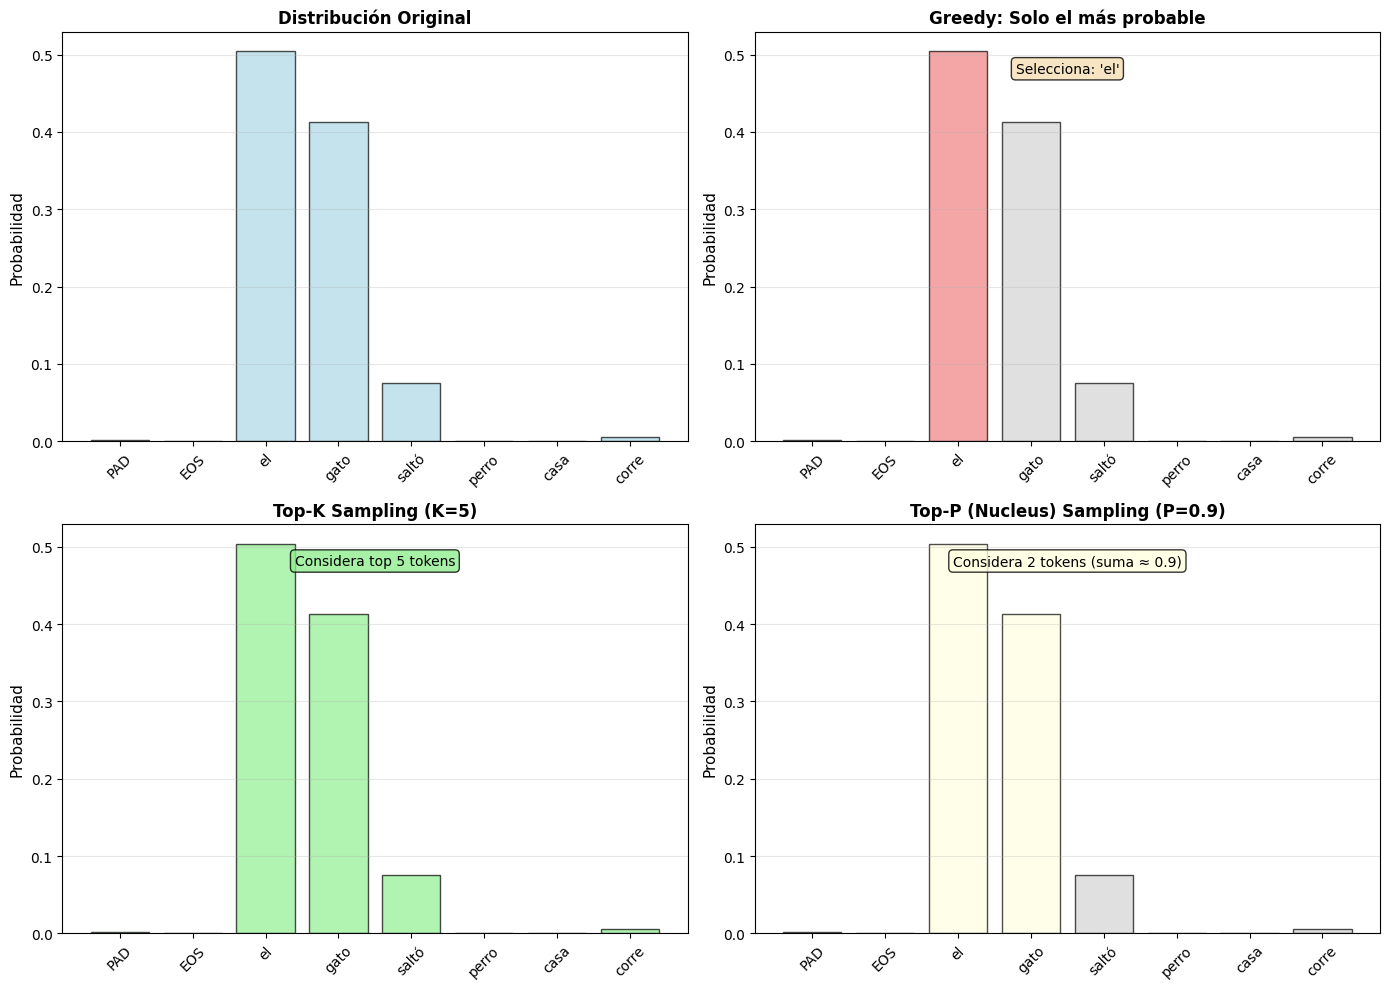

Comparación de Estrategias de Muestreo

Estrategia           Tokens Considerados            Diversidad     
------------------------------------------------------------
Greedy               1                              Baja           
Top-K (K=5)          5                              Media          
Top-P (P=0.9)        2                              Dinámica       

Top-P (P=0.9) - Proceso de selección:
Token            Prob    Cum. Prob ¿Incluido?  
---------------------------------------------
el             0.5044       0.5044 Sí          
gato           0.4129       0.9173 Sí          
saltó          0.0754       0.9927 No          
corre          0.0051       0.9978 No          
PAD            0.0015       0.9993 No          
casa           0.0004       0.9997 No          
EOS            0.0003       1.0000 No          
perro          0.0000       1.0000 No          


In [15]:
# Visualización de estrategias
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución original
ax = axes[0, 0]
ax.bar(tokens, probs, color='lightblue', alpha=0.7, edgecolor='black')
ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title('Distribución Original', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# 2. Greedy
ax = axes[0, 1]
colors_greedy = ['lightcoral' if i == np.argmax(probs) else 'lightgray' for i in range(len(probs))]
ax.bar(tokens, probs, color=colors_greedy, alpha=0.7, edgecolor='black')
ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title('Greedy: Solo el más probable', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
selected = tokens[np.argmax(probs)]
ax.text(0.5, 0.9, f"Selecciona: '{selected}'",
        transform=ax.transAxes, ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 3. Top-K
ax = axes[1, 0]
k = 5
top_k_indices = np.argsort(probs)[-k:]
colors_topk = ['lightgreen' if i in top_k_indices else 'lightgray' for i in range(len(probs))]
ax.bar(tokens, probs, color=colors_topk, alpha=0.7, edgecolor='black')
ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title(f'Top-K Sampling (K={k})', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.text(0.5, 0.9, f"Considera top {k} tokens",
        transform=ax.transAxes, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# 4. Top-P
ax = axes[1, 1]
p = 0.9
sorted_indices = np.argsort(probs)[::-1]
sorted_probs = probs[sorted_indices]
cumsum_probs = np.cumsum(sorted_probs)
nucleus_size = np.searchsorted(cumsum_probs, p) + 1
nucleus_indices = sorted_indices[:nucleus_size]

colors_topp = ['lightyellow' if i in nucleus_indices else 'lightgray' for i in range(len(probs))]
ax.bar(tokens, probs, color=colors_topp, alpha=0.7, edgecolor='black')
ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title(f'Top-P (Nucleus) Sampling (P={p})', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.text(0.5, 0.9, f"Considera {nucleus_size} tokens (suma ≈ {p})",
        transform=ax.transAxes, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Simulación de muestreo
print("Comparación de Estrategias de Muestreo")
print("=" * 60)
print(f"\n{'Estrategia':<20} {'Tokens Considerados':<30} {'Diversidad':<15}")
print("-" * 60)
print(f"{'Greedy':<20} {1:<30} {'Baja':<15}")
print(f"{'Top-K (K=5)':<20} {k:<30} {'Media':<15}")
print(f"{'Top-P (P=0.9)':<20} {nucleus_size:<30} {'Dinámica':<15}")

# Mostrar probabilidades acumuladas para Top-P
print(f"\nTop-P (P={p}) - Proceso de selección:")
print(f"{'Token':<10} {'Prob':>10} {'Cum. Prob':>12} {'¿Incluido?':<12}")
print("-" * 45)
for i, idx in enumerate(sorted_indices):
    cumprob = cumsum_probs[i]
    included = "Sí" if idx in nucleus_indices else "No"
    print(f"{tokens[idx]:<10} {probs[idx]:>10.4f} {cumprob:>12.4f} {included:<12}")

**Ventaja:** Dinámico; ajusta el número de tokens según la distribución
**Desventaja:** Requiere más computación (ordenar)

### Comparación Visual

```
Distribución original: [0.35, 0.32, 0.18, 0.07, 0.05, 0.03, ...]

Greedy:     Elige 0.35 (token 0)

Top-5:      Considera [0.35, 0.32, 0.18, 0.07, 0.05]
            Renormaliza: [0.37, 0.34, 0.19, 0.07, 0.03]
            Muestrea aleatoriamente

Top-P(0.9): Suma [0.35, 0.32, 0.18, 0.07] = 0.92 > 0.9
            Considera [0.35, 0.32, 0.18, 0.07]
            Renormaliza: [0.38, 0.35, 0.20, 0.08]
            Muestrea aleatoriamente
```

:::{figure} images/AI_03_03_Generation_Cost_Token_Count.jpeg
:name: fig-generation-cost
:alt: Costo de generación por número de tokens
:align: center
:width: 90%

**Figura 3:** Costo de Generación - el tiempo y costo escalan linealmente con el número de tokens generados.
:::

---

## Parte 4: Beam Search

Beam search es más complejo pero potente: en lugar de elegir un token, explora múltiples caminos.

### Idea Conceptual

```
Paso 1: Genera los K mejores tokens (ej: K=3)
  Beam 1: "el" (probabilidad acumulada = 0.35)
  Beam 2: "gato" (probabilidad acumulada = 0.32)
  Beam 3: "saltó" (probabilidad acumulada = 0.18)

Paso 2: Para cada beam, genera el siguiente token
  Beam 1 ("el"):    mejores opciones: [" gato" P=0.40, " perro" P=0.30, ...]
  Beam 2 ("gato"):  mejores opciones: [" saltó" P=0.50, " corrió" P=0.25, ...]
  Beam 3 ("saltó"): mejores opciones: [" sobre" P=0.60, ...]

Paso 3: Calcula probabilidades acumuladas de cada secuencia
  "el gato": 0.35 * 0.40 = 0.14
  "el perro": 0.35 * 0.30 = 0.105
  "gato saltó": 0.32 * 0.50 = 0.16
  "gato corrió": 0.32 * 0.25 = 0.08
  "saltó sobre": 0.18 * 0.60 = 0.108
  ...

Paso 4: Mantén los K mejores caminos
  Ranking: 1) "gato saltó" (0.16), 2) "el gato" (0.14), 3) "saltó sobre" (0.108), ...
  Nuevos beams (K=3):
    Beam 1: "gato saltó"
    Beam 2: "el gato"
    Beam 3: "saltó sobre"

Repite hasta longitud máxima o hasta que generes [END]
```

**Ventaja:** Explora múltiples caminos, mejor probabilidad general  
**Desventaja:** Computacionalmente costoso; requiere mantener múltiples secuencias

### Implementación de Beam Search

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def beam_search(log_prob_fn, initial_token, vocab, beam_width=3, max_steps=4):
    """
    Beam Search simplificado.

    Args:
        log_prob_fn: función que dado una secuencia devuelve log-probs del siguiente token
        initial_token: token de inicio (índice en vocab)
        vocab: lista de tokens (strings)
        beam_width: número de beams a mantener (K)
        max_steps: número máximo de tokens a generar

    Returns:
        Lista de (log_prob, secuencia) de los mejores beams al final
        Historia de expansiones para visualización
    """
    # Cada beam: (log_probabilidad_acumulada, lista_de_tokens)
    beams = [(0.0, [initial_token])]
    history = [list(beams)]  # para visualizar el árbol

    for step in range(max_steps):
        candidates = []
        for log_prob, tokens in beams:
            # Obtener distribución sobre siguiente token
            next_log_probs = log_prob_fn(tokens)

            # Expandir: considerar todos los tokens del vocabulario
            for token_idx, token_log_prob in enumerate(next_log_probs):
                new_log_prob = log_prob + token_log_prob
                candidates.append((new_log_prob, tokens + [token_idx]))

        # Mantener solo los K mejores candidatos (por log-prob acumulada)
        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_width]
        history.append(list(beams))

    return beams, history


# Vocabulario simplificado de prueba
vocab = ['[START]', 'el', 'gato', 'saltó', 'sobre', 'la', 'cerca', '[END]']
V = len(vocab)

# Distribución de siguiente token simulada (para demostración)
# En la práctica, esto sería el LLM
np.random.seed(7)
transition_matrix = np.random.dirichlet(np.ones(V) * 0.5, size=V)

def log_prob_fn(token_sequence):
    """Distribución de siguiente token dado el último token."""
    last_token = token_sequence[-1]
    return np.log(transition_matrix[last_token] + 1e-10)

# Ejecutar beam search desde [START] (token 0)
best_beams, history = beam_search(log_prob_fn, initial_token=0, vocab=vocab,
                                   beam_width=3, max_steps=4)

# Resultados
print("=== Beam Search (K=3) ===")
print(f"Vocabulario: {vocab}\n")
for rank, (lp, seq) in enumerate(best_beams, 1):
    words_seq = [vocab[t] for t in seq]
    print(f"  Beam {rank}: {' '.join(words_seq):30s}  log-prob={lp:.3f}  prob={np.exp(lp):.6f}")

=== Beam Search (K=3) ===
Vocabulario: ['[START]', 'el', 'gato', 'saltó', 'sobre', 'la', 'cerca', '[END]']

  Beam 1: [START] saltó el [START] saltó  log-prob=-3.856  prob=0.021157
  Beam 2: [START] saltó sobre [END] saltó  log-prob=-3.910  prob=0.020049
  Beam 3: [START] saltó el [START] cerca  log-prob=-4.185  prob=0.015217


Un árbol de búsqueda de Beam Search ilustra a la perfección por qué es tan computacionalmente costoso en memoria este método exploratorio de caminos algorítmicos.

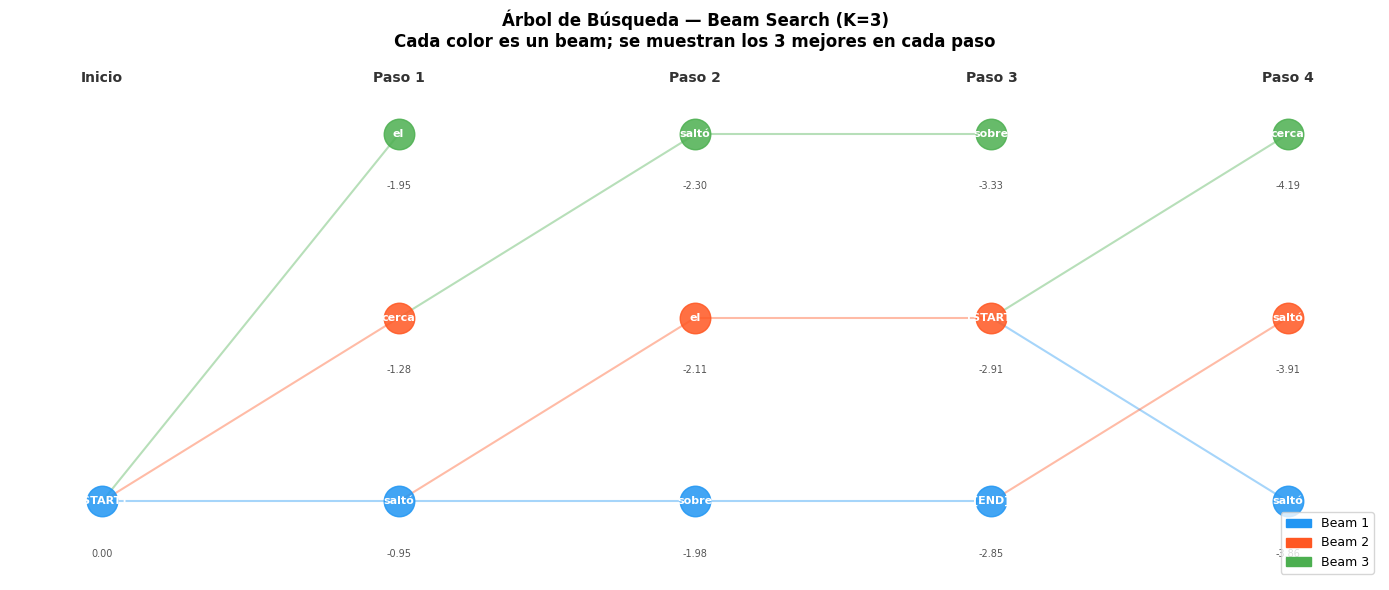


Comparación de estrategias de decoding:
  Greedy:      1 camino,  determinístico, rápido
  Top-K/Top-P: 1 camino,  estocástico,   rápido
  Beam Search: 3 caminos, determinístico, más lento


In [17]:
# Visualización del árbol de búsqueda
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#2196F3', '#FF5722', '#4CAF50']  # azul, naranja, verde para cada beam

step_labels = ['Inicio', 'Paso 1', 'Paso 2', 'Paso 3', 'Paso 4']
x_positions = np.linspace(0.05, 0.95, len(history))

# Dibujar nodos y conexiones
prev_coords = {}  # mapa de seq_tuple → (x, y) de nodo anterior

for step_idx, (step_beams, x_pos) in enumerate(zip(history, x_positions)):
    n = len(step_beams)
    y_positions = np.linspace(0.15, 0.85, max(n, 1))

    for beam_rank, ((lp, seq), y_pos) in enumerate(zip(step_beams, y_positions)):
        label = vocab[seq[-1]] if seq else '[START]'
        color = colors[beam_rank % len(colors)]

        # Nodo
        ax.plot(x_pos, y_pos, 'o', markersize=22,
                color=color, alpha=0.85, zorder=3)
        ax.text(x_pos, y_pos, label, ha='center', va='center',
                fontsize=8, weight='bold', color='white', zorder=4)
        ax.text(x_pos, y_pos - 0.09, f'{lp:.2f}',
                ha='center', va='top', fontsize=7, color='#555555')

        # Línea al padre
        if step_idx > 0:
            parent_seq = tuple(seq[:-1])
            if parent_seq in prev_coords:
                px, py = prev_coords[parent_seq]
                ax.plot([px, x_pos], [py, y_pos], '-',
                        color=color, alpha=0.4, linewidth=1.5, zorder=2)

        prev_coords[tuple(seq)] = (x_pos, y_pos)

# Etiquetas de pasos
for i, (label, x) in enumerate(zip(step_labels, x_positions)):
    ax.text(x, 0.97, label, ha='center', va='top',
            fontsize=10, weight='bold', color='#333333',
            transform=ax.transAxes if False else ax.transData)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.0, 1.0)
ax.axis('off')
ax.set_title(f'Árbol de Búsqueda — Beam Search (K=3)\n'
             f'Cada color es un beam; se muestran los 3 mejores en cada paso',
             fontsize=12, weight='bold')

legend_handles = [mpatches.Patch(color=c, label=f'Beam {i+1}')
                  for i, c in enumerate(colors)]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nComparación de estrategias de decoding:")
print(f"  Greedy:      1 camino,  determinístico, rápido")
print(f"  Top-K/Top-P: 1 camino,  estocástico,   rápido")
print(f"  Beam Search: {3} caminos, determinístico, más lento")

---


## Parte 5: Entrenamiento - Cross-Entropy Loss

¿Cómo entrenan estos modelos a generar el token correcto?

### La Tarea de Entrenamiento

```
Texto: "El gato saltó sobre la cerca"
Tokenizado: [token_el, token_gato, token_saltó, ...]

Reorganiza como pares entrada-salida:
Entrada: [token_el] → Salida esperada: token_gato
Entrada: [token_el, token_gato] → Salida esperada: token_saltó
Entrada: [token_el, token_gato, token_saltó] → Salida esperada: token_sobre
...

Esto se llama "next-token prediction" o "causal language modeling".
```

### Cross-Entropy Loss

Para cada predicción:

```
Modelo produce:
P(token_gato) = 0.35
P(token_saltó) = 0.20
P(token_perro) = 0.15
...

La verdadera etiqueta es: token_gato (P=1.0)

Cross-Entropy Loss = -log(0.35) ≈ 1.05

Si el modelo predice correctamente (P=0.99):
Loss = -log(0.99) ≈ 0.01

Si predice incorrectamente (P=0.01):
Loss = -log(0.01) ≈ 4.6
```

**Fórmula:**
```
CE Loss = -Σ y_i * log(ŷ_i)

donde:
- y es la distribución verdadera (1 para la palabra correcta, 0 para otras)
- ŷ es la distribución predicha (softmax de logits)
```

### Entrenamiento

```
Para cada batch de ejemplos:
  1. Forward pass: predice probabilidades para cada posición
  2. Calcula CE loss para cada predicción
  3. Promedia los losses
  4. Retropropagación: actualiza pesos para reducir loss
  5. Repite con el siguiente batch

Después de 100 mil millones de tokens de entrenamiento,
el modelo ha aprendido patrones de lenguaje.
```

---

## Parte 6: Tokenización - BPE

¿Cómo convertimos texto en tokens?

### Problema

Vocabulario completo de caracteres: ~10,000 caracteres en Unicode
Vocabulario de palabras: millones (cada palabra es única)
Solución intermedia: **Byte Pair Encoding (BPE)**

### Algoritmo BPE Simplificado

```
Paso 1: Comienza con caracteres
  Vocabulario: [a, b, c, d, e, ...]

Paso 2: Busca el par más común, reemplázalo con un nuevo símbolo
  Documento: "aabaaaab"
  Par más común: "aa"
  Nuevo símbolo: X
  Documento: "XbXXb"
  Vocabulario: [a, b, c, ..., X]

Paso 3: Repite N veces (típicamente N=30,000)
  "XbXXb"
  Par más común: "Xb"
  Nuevo símbolo: Y
  "YXY"
  etc.

Resultado: Vocabulario de ~50,000 "tokens" que combinan caracteres y palabras.
```

In [18]:
from collections import Counter
import re

def get_stats(vocab):
    """Cuenta pares de símbolos consecutivos"""
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[symbols[i], symbols[i + 1]] += freq
    return pairs

def merge_vocab(pair, vocab):
    """Fusiona el par más frecuente en el vocabulario"""
    new_vocab = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)

    for word in vocab:
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = vocab[word]
    return new_vocab

# Simulación simple de BPE
print("Byte Pair Encoding (BPE) - Demostración")
print("=" * 60)

# Vocabulario inicial (palabras con frecuencias)
vocab = {
    'l o w </w>': 5,
    'l o w e r </w>': 2,
    'n e w e s t </w>': 6,
    'w i d e s t </w>': 3
}

print("\nVocabulario inicial (palabras divididas en caracteres):")
for word, freq in vocab.items():
    print(f"  '{word}': {freq} veces")

num_merges = 10
merges_history = []

print(f"\nAplicando {num_merges} fusiones BPE:")
print("-" * 60)

for i in range(num_merges):
    pairs = get_stats(vocab)
    if not pairs:
        break

    best_pair = max(pairs, key=pairs.get)
    vocab = merge_vocab(best_pair, vocab)
    merges_history.append(best_pair)

    print(f"\nFusión {i+1}: {best_pair[0]} + {best_pair[1]} = {''.join(best_pair)}")
    print(f"  Frecuencia del par: {pairs[best_pair]}")
    print(f"  Vocabulario actualizado:")
    for word, freq in vocab.items():
        print(f"    '{word}': {freq} veces")

print(f"\nHistorial de fusiones:")
for i, (a, b) in enumerate(merges_history, 1):
    print(f"  {i}. '{a}' + '{b}' → '{a}{b}'")

Byte Pair Encoding (BPE) - Demostración

Vocabulario inicial (palabras divididas en caracteres):
  'l o w </w>': 5 veces
  'l o w e r </w>': 2 veces
  'n e w e s t </w>': 6 veces
  'w i d e s t </w>': 3 veces

Aplicando 10 fusiones BPE:
------------------------------------------------------------

Fusión 1: e + s = es
  Frecuencia del par: 9
  Vocabulario actualizado:
    'l o w </w>': 5 veces
    'l o w e r </w>': 2 veces
    'n e w es t </w>': 6 veces
    'w i d es t </w>': 3 veces

Fusión 2: es + t = est
  Frecuencia del par: 9
  Vocabulario actualizado:
    'l o w </w>': 5 veces
    'l o w e r </w>': 2 veces
    'n e w est </w>': 6 veces
    'w i d est </w>': 3 veces

Fusión 3: est + </w> = est</w>
  Frecuencia del par: 9
  Vocabulario actualizado:
    'l o w </w>': 5 veces
    'l o w e r </w>': 2 veces
    'n e w est</w>': 6 veces
    'w i d est</w>': 3 veces

Fusión 4: l + o = lo
  Frecuencia del par: 7
  Vocabulario actualizado:
    'lo w </w>': 5 veces
    'lo w e r </w>': 2 ve

Ahora, veamos analíticamente cómo esta estrategia heurística iterativa ayuda a reducir el costo computacional de codificar cadenas de texto (es decir, reducir el la cantidad de *tokens* requeridos por oración).

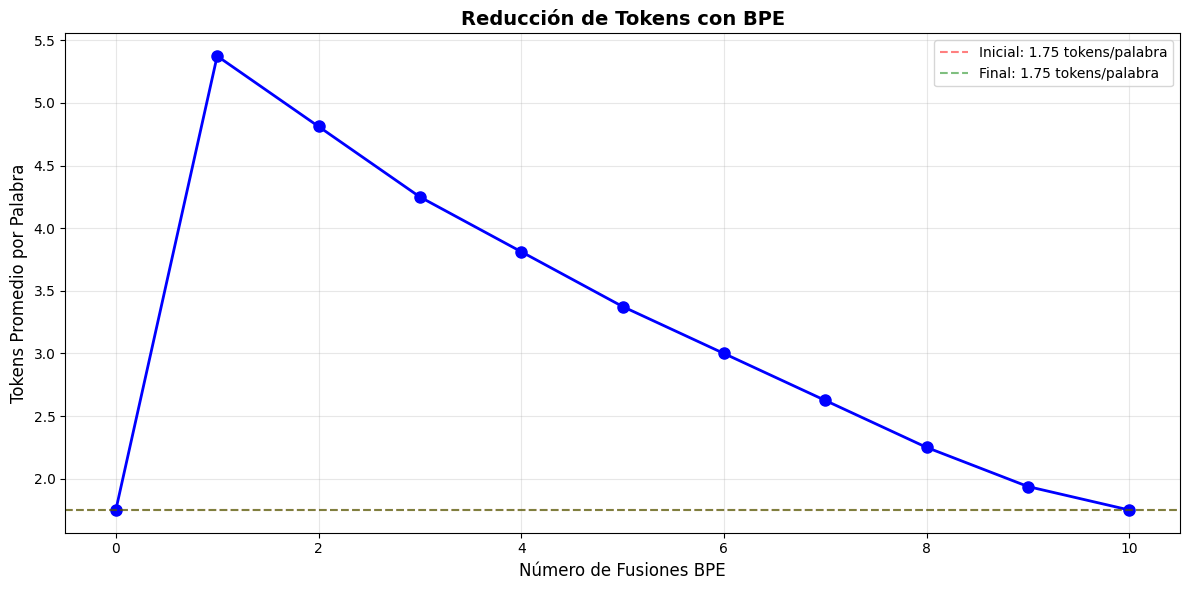


Reducción: 1.75 → 1.75 tokens/palabra
Compresión: 0.0%


In [19]:
# Visualización
import matplotlib.pyplot as plt

# Crear visualización del proceso
fig, ax = plt.subplots(figsize=(12, 6))

# Mostrar progresión del tamaño promedio de tokens
initial_tokens = sum(len(word.split()) * freq for word, freq in vocab.items()) / sum(vocab.values())
steps = list(range(len(merges_history) + 1))
avg_token_counts = [initial_tokens]

# Recalcular para cada paso (simplificado)
temp_vocab = {
    'l o w </w>': 5,
    'l o w e r </w>': 2,
    'n e w e s t </w>': 6,
    'w i d e s t </w>': 3
}

for pair in merges_history:
    temp_vocab = merge_vocab(pair, temp_vocab)
    avg_tokens = sum(len(word.split()) * freq for word, freq in temp_vocab.items()) / sum(temp_vocab.values())
    avg_token_counts.append(avg_tokens)

ax.plot(steps, avg_token_counts, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Número de Fusiones BPE', fontsize=12)
ax.set_ylabel('Tokens Promedio por Palabra', fontsize=12)
ax.set_title('Reducción de Tokens con BPE', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=avg_token_counts[0], color='red', linestyle='--', alpha=0.5,
           label=f'Inicial: {avg_token_counts[0]:.2f} tokens/palabra')
ax.axhline(y=avg_token_counts[-1], color='green', linestyle='--', alpha=0.5,
           label=f'Final: {avg_token_counts[-1]:.2f} tokens/palabra')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nReducción: {avg_token_counts[0]:.2f} → {avg_token_counts[-1]:.2f} tokens/palabra")
print(f"Compresión: {(1 - avg_token_counts[-1]/avg_token_counts[0])*100:.1f}%")

### Ventajas de BPE

```
Palabra: "unbelievable"
Caracteres: [u, n, b, e, l, i, e, v, a, b, l, e] - 12 símbolos

Con BPE:
Si "un" es común → token UN
Si "able" es común → token ABLE
Si "beli" es común → token BELI
Resultado: [UN, BELI, EV, ABLE] - 4 tokens

Económico: menos tokens = menor costo computacional
Flexible: palabras desconocidas se descomponen en sub-palabras
```

### Otros métodos

- **WordPiece (BERT):** Similar a BPE, pero usa probabilidad en lugar de frecuencia
- **SentencePiece:** Comienza con caracteres Unicode, no ASCII

---

## Parte 7: En Resumen: El Pipeline Completo

```
Entrada: "¿Cuál es la capital de Francia?"
           ↓
[Tokenización BPE]: [¿, Cuál, es, la, capital, de, Francia, ?]
           ↓
[Embeddings + Pos Encoding]
           ↓
[Transformer Bloques] × N
           ↓
[Proyección a Logits]: [logit_0, logit_1, ..., logit_50256]
           ↓
[Softmax]: [P(token_0), P(token_1), ..., P(token_50256)]
           ↓
[Sampling: Top-P (P=0.9), T=1.0]
           ↓
[Token Elegido]: token_Paris (P=0.42)
           ↓
Salida: "París"
           ↓
[Repite con nueva entrada]: "¿Cuál es la capital de Francia? París"
```

---


## Implementando la Generación Paso a Paso (PyTorch)

Para quitarle la "magia" a las librerías como HuggingFace, vamos a implementar nosotros mismos el ciclo autoregresivo exacto usando un modelo de lenguaje real (GPT-2).

In [20]:
import torch
from transformers import AutoTokenizer, GPT2LMHeadModel

# 1. Cargar modelo pequeño y tokenizer
model_id = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = GPT2LMHeadModel.from_pretrained(model_id)
model.eval()

# 2. Entrada inicial (Prompt)
text = "The capital of France is"
inputs = tokenizer(text, return_tensors="pt")

print(f"Texto original: '{text}'")
print(f"Tokens de entrada (IDs): {inputs['input_ids'][0].tolist()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Texto original: 'The capital of France is'
Tokens de entrada (IDs): [464, 3139, 286, 4881, 318]


Una vez que configuramos el Prompt junto con el *Tokenizer/Embeddings*, observemos detalladamente en este ciclo `for` iterativo cómo se extrae el vector logit, se decide el token, **y se retroalimenta para el siguiente turno**, es decir: *generación autoregresiva manual*.

In [21]:
# 3. Generación Autoregresiva Manual (Paso a paso)
max_new_tokens = 5
current_input_ids = inputs['input_ids']

print("\nIniciando generación iterativa...")
print("-" * 50)

with torch.no_grad():
    for step in range(max_new_tokens):
        # A) Forward pass: pasar todos los tokens actuales por el transformer
        outputs = model(input_ids=current_input_ids)

        # B) Extraer los logits de la ÚLTIMA posición generada
        # outputs.logits tiene forma: [batch_size, sequence_length, vocab_size]
        next_token_logits = outputs.logits[0, -1, :]

        # C) Selección del siguiente token (Greedy Decoding: argmax)
        next_token_id = torch.argmax(next_token_logits)

        # D) Decodificar para ver qué palabra eligió
        next_word = tokenizer.decode(next_token_id)

        print(f"Paso {step+1} | Token ID: {next_token_id.item():>5} | Palabra: '{next_word}'")

        # E) Agregar el nuevo token a la secuencia para el siguiente paso (Autoregresivo!)
        current_input_ids = torch.cat([current_input_ids, next_token_id.unsqueeze(0).unsqueeze(0)], dim=-1)

print("-" * 50)
print(f"Texto final completo: '{tokenizer.decode(current_input_ids[0])}'")


Iniciando generación iterativa...
--------------------------------------------------
Paso 1 | Token ID:   262 | Palabra: ' the'
Paso 2 | Token ID:  3139 | Palabra: ' capital'
Paso 3 | Token ID:   286 | Palabra: ' of'
Paso 4 | Token ID:   262 | Palabra: ' the'
Paso 5 | Token ID:  4141 | Palabra: ' French'
--------------------------------------------------
Texto final completo: 'The capital of France is the capital of the French'


Como puedes ver, `model.generate()` simplemente oculta este ciclo `for` detrás de una función fácil de usar. Cada palabra generada obliga al modelo a recalcular todo el contexto anterior.

## Reflexión y Ejercicios

### Preguntas para Reflexionar:

1. **Temperature:** ¿Por qué un chatbot interactivo usa T=1.0 pero un traductor automático usa T=0.1?

2. **Beam Search vs Sampling:** ¿Cuándo elegirías beam search? ¿Cuándo Top-P sampling?

3. **Cross-Entropy Loss:** ¿Por qué usamos logaritmo? ¿Qué pasaría si simplemente usáramos |y - ŷ|?

### Ejercicios Prácticos:

1. **Softmax manual:**
   ```
   Logits: [2.0, 0.5, 1.5]
   Calcula softmax y obtén probabilidades para cada token.
   ```

2. **BPE simulado:**
   ```
   Documento: "aaabaaab"
   Paso 1: ¿Cuál es el par más común?
   Paso 2: Reemplázalo con símbolo X. Nuevo documento: ?
   Paso 3: ¿Cuál es el siguiente par más común?
   ```

3. **Análisis: Greedy vs Top-P**
   ```
   Supón que tienes dos probabilidades de distribución:

   Caso 1: [0.9, 0.05, 0.03, 0.02, ...]
   Caso 2: [0.2, 0.2, 0.2, 0.2, 0.2]

   Para cada caso, ¿qué estrategia (greedy, top-K, top-P) elegirías?
   ¿Por qué?
   ```

4. **Reflexión escrita (300 palabras):** "Los LLMs se entrenan con cross-entropy loss en tareas de next-token prediction. ¿Cómo crees que esto lo hace buenos en tareas que no son predicción del siguiente token, como responder preguntas o resumir?"

---

```{admonition} ✅ Verifica tu comprensión
:class: note
1. ¿Cuál es la diferencia entre logits y probabilidades? ¿Por qué necesitamos softmax?
2. Explica con tus palabras por qué Top-P sampling es más flexible que Top-K.
3. ¿Cuándo elegirías beam search sobre Top-P sampling? Menciona un caso de uso específico.
4. ¿Por qué cross-entropy loss usa logaritmo? ¿Qué pasaría si usáramos simplemente |y - ŷ|?
```

## Errores Comunes

```{admonition} ⚠️ Errores frecuentes
:class: warning

1. **Confundir logits con probabilidades**: Logits son scores sin normalizar (pueden ser negativos o >1). Aplica softmax antes de interpretar como probabilidades.
2. **Temperatura mal aplicada**: Dividir logits por T **antes** de softmax, no después. `softmax(logits/T)` ≠ `softmax(logits)/T`.
3. **Top-K con K muy pequeño**: K=1 es greedy. K=5 puede excluir tokens correctos en distribuciones planas. Ajusta según varianza de logits.
4. **Olvidar el token EOS**: Sin condición de parada, el modelo genera indefinidamente. Siempre verifica `if next_token == eos_token: break`.
5. **BPE inconsistente**: Usar tokenizador diferente al del modelo causa errores silenciosos. Siempre usa `tokenizer = AutoTokenizer.from_pretrained(model_name)`.
6. **Cross-entropy con índices incorrectos**: El target debe ser el índice del token correcto, no un vector one-hot. Verifica `loss = F.cross_entropy(logits, labels)`.
```

## Resumen

```{admonition} Resumen
:class: important
**Conceptos clave:**
- Generación autoregresiva: modelo predice siguiente token basado en tokens anteriores, repite iterativamente
- Softmax convierte logits (scores sin normalizar) a distribución de probabilidad; temperatura controla distribución
- Estrategias de muestreo: greedy (determinístico), Top-K/Top-P (balancean creatividad y coherencia), beam search (explora múltiples caminos)
- Cross-entropy loss mide qué tan bien el modelo predice tokens correctos; minimizar durante entrenamiento
- Tokenización BPE descompone palabras en sub-palabras, balanceando eficiencia y flexibilidad (~30-50k tokens de vocabulario)

**Para la siguiente lectura:** Prepárate para profundizar en la arquitectura Transformer. Veremos en detalle el mecanismo de atención, multi-head attention y codificación posicional que hacen posible la generación que acabamos de estudiar.
```

## Puntos Clave

- **Logits → Softmax:** Convierte salida de modelo en probabilidades
- **Temperatura:** Controla "agudeza" de distribución (baja = determinístico, alta = aleatorio)
- **Greedy:** Elige token más probable (rápido, a menudo aburrido)
- **Top-K/Top-P:** Excluye tokens improbables, muestrea aleatoriamente (creativo, pero controlado)
- **Beam Search:** Explora múltiples caminos (mejor calidad, más lento)
- **Cross-Entropy Loss:** -log(P_correcta), minimizar durante entrenamiento
- **BPE:** Divide palabras en sub-palabras (balance entre caracteres y palabras)

---

## Referencias

- Sennrich, R., Haddow, B., & Birch, A. (2016). [Neural Machine Translation of Rare Words with Subword Units](https://arxiv.org/abs/1508.07909). arXiv:1508.07909.
- Holtzman, A. et al. (2020). [The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751). ICLR 2020.
- Fan, A., Lewis, M., & Dauphin, Y. (2018). [Hierarchical Neural Story Generation](https://arxiv.org/abs/1805.04833). ACL.
- Radford, A. et al. (2019). [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf). OpenAI.